<a href="https://colab.research.google.com/github/joaoalexandre14/AVCAD_final_project/blob/main/projetoAVCAD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Relationship between socio-economic variables and agricultural activities in Alentejo parishes

## 1. Introduction
#### **Background**
Agriculture in Alentejo plays an important economic and territorial role and is increasingly affected by demographic changes within agricultural populations. Aging producers and lower educational attainment may influence decisions regarding agricultural practices and land-use organization. Understanding whether socio-demographic characteristics are associated with agricultural patterns may help identify structural challenges affecting agricultural sustainability and adaptation.

#### **Question**
How does the demographic profile of agricultural producers influence land-use patterns in Alentejo?

#### **Hypotheses**
*   H1: Parishes with older agricultural populations have lower prevalence/proportion of temporary crops
*   H2: Higher producer aging is associated with greater prevalence of permanent crops
*   H3: Lower education levels are positively associated with producer aging
*   H4: Aging and education jointly explain variation in agricultural land-use patterns

#### **Objective**
Analyze whether demographic aging and educational characteristics of agricultural populations are associated with differences in agricultural land use across Alentejo parishes.

## 2. Database description

### Study design
This study uses a cross-sectional observational design based on parish-level data from Alentejo. Data from multiple agricultural and demographic datasets were integrated using a unique geographic identifier. Derived indicators were subsequently constructed and analyzed using descriptive statistics, exploratory visualizations and inferential methods.

### Data sources
Five datasets from the Portuguese National Statistics Institute (INE) were used and integrated at the parish level. The datasets represent demographic characteristics of agricultural producers and agricultural land-use indicators. The analytical unit corresponds to civil parishes in Alentejo.

### Auxiliary functions and configuration
Raw INE files contain metadata structures and non-standard numeric formatting. Auxiliary functions were therefore created to extract geographic identifiers and convert values into a consistent numerical format suitable for analysis.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import re

# Função atualizada para extrair também a chave de 6 dígitos do INE
def ler_ine_seguro(filepath, geo_col_idx):
    data = []
    with open(filepath, 'r', encoding='latin-1') as f:
        for line in f:
            cols = line.strip('\n').split(';')
            if len(cols) > geo_col_idx:
                geo_val = cols[geo_col_idx].strip()
                if re.match(r'^\d+:', geo_val):
                    # Extrai os últimos 6 dígitos do código antes dos dois pontos (Chave Única)
                    chave = geo_val.split(':')[0].strip()[-6:]
                    nome = geo_val.split(':')[1].strip()

                    cols[geo_col_idx] = nome
                    # Adiciona a chave no fim para não estragar a contagem das tuas colunas originais
                    cols.append(chave)
                    data.append(cols)
    return pd.DataFrame(data)

def limpar_numerico(serie):
    s = serie.astype(str).str.replace('.', '', regex=False)
    s = s.str.replace(',', '.', regex=False)
    s = s.str.replace(r'^\s*-\s*-\s*$', '0', regex=True)
    return pd.to_numeric(s, errors='coerce').fillna(0)

print("Célula 1 concluída! Funções de tratamento prontas.")

Célula 1 concluída! Funções de tratamento prontas.


The functions allow automatic extraction of the unique geographic code (Chave_Geo) and standardization of numerical values, ensuring consistency across all datasets.

### Raw data loading
The original datasets were imported separately before cleaning and transformation procedures.

In [ ]:
df_total_raw = ler_ine_seguro('Produtores_Total.csv', geo_col_idx=1)
df_idosos_raw = ler_ine_seguro('Produtores_Idosos.csv', geo_col_idx=0)
df_educacao_raw = ler_ine_seguro('Produtores_Educacao.csv', geo_col_idx=0)
df_culturas_raw = ler_ine_seguro('Superficie_Culturas.csv', geo_col_idx=1)
df_media_raw = ler_ine_seguro('Superficie_Media.csv', geo_col_idx=0)

print("Célula 2 concluída! Os 5 ficheiros foram mapeados e limpos de metadados.")

Célula 2 concluída! Os 5 ficheiros foram mapeados e limpos de metadados.


Five independent datasets were successfully loaded and prepared for variable extraction.

### Variable extraction
Relevant variables were selected from each raw dataset and renamed to produce a cleaner analytical structure.

In [ ]:
# Mapeamento incluindo a Chave_Geo
t_total_clean = pd.DataFrame({
    'Chave_Geo': df_total_raw.iloc[:, -1],
    'Nome_Freguesia': df_total_raw[1],
    'Total_Produtores': limpar_numerico(df_total_raw[2])
})

t_idosos_clean = pd.DataFrame({
    'Chave_Geo': df_idosos_raw.iloc[:, -1],
    'Total_Idosos': limpar_numerico(df_idosos_raw[1])
})

t_educacao_clean = pd.DataFrame({
    'Chave_Geo': df_educacao_raw.iloc[:, -1],
    'Percentagem_Baixa_Escolaridade': limpar_numerico(df_educacao_raw[2]) + limpar_numerico(df_educacao_raw[3])
})

t_culturas_clean = pd.DataFrame({
    'Chave_Geo': df_culturas_raw.iloc[:, -1],
    'Area_Temporarias': limpar_numerico(df_culturas_raw[2]),
    'Area_Permanentes': limpar_numerico(df_culturas_raw[3])
})

t_media_clean = pd.DataFrame({
    'Chave_Geo': df_media_raw.iloc[:, -1],
    'Superficie_Media_Exploracao': limpar_numerico(df_media_raw[1])
})

print("Célula 3 concluída! Variáveis numéricas normalizadas.")

Célula 3 concluída! Variáveis numéricas normalizadas.


The selected variables include demographic indicators (number of producers, elderly producers, education level) and agricultural indicators (temporary and permanent crop areas).

### Data integration
Individual datasets were integrated through the unique geographic identifier (Chave_Geo), allowing parish-level observations to be matched while avoiding problems associated with duplicate parish names.

In [ ]:
# Cruzamento em cadeia utilizando a Chave_Geo (Única e sem erros de homónimos)
df_final = pd.merge(t_total_clean, t_idosos_clean, on='Chave_Geo', how='inner')
df_final = pd.merge(df_final, t_educacao_clean, on='Chave_Geo', how='inner')
df_final = pd.merge(df_final, t_culturas_clean, on='Chave_Geo', how='inner')

# Usamos 'left' para o 5º ficheiro para NÃO perder as freguesias que faltam!
df_final = pd.merge(df_final, t_media_clean, on='Chave_Geo', how='left')

# Onde o 5º ficheiro não tinha dados, assume 0 para não quebrar os gráficos
df_final['Superficie_Media_Exploracao'] = df_final['Superficie_Media_Exploracao'].fillna(0)

A chained merging procedure generated a unified analytical dataset containing 299 Alentejo parishes after integration and quality verification procedures.

### Data quality checks

In [ ]:
print(df_final.isnull().sum())
print(df_final.duplicated().sum())

Chave_Geo                         0
Nome_Freguesia                    0
Total_Produtores                  0
Total_Idosos                      0
Percentagem_Baixa_Escolaridade    0
Area_Temporarias                  0
Area_Permanentes                  0
Superficie_Media_Exploracao       0
dtype: int64
0


Data quality verification indicated no duplicated parish observations after dataset integration. Missing values originating from average farm area information were replaced by zero only when necessary to preserve parish records.

### Variable construction
Additional indicators were constructed from existing variables to facilitate interpretation and statistical analysis.


In [ ]:
# Construção da taxa de envelhecimento relativo (%)
df_final['Percentagem_Envelhecimento'] = (df_final['Total_Idosos'] / df_final['Total_Produtores']) * 100
df_final['Percentagem_Envelhecimento'] = df_final['Percentagem_Envelhecimento'].fillna(0).round(2)

# Normalização das áreas agrícolas
df_final['Area_Total_Culturas'] = (df_final['Area_Temporarias'] + df_final['Area_Permanentes'])

df_final['Perc_Temporarias'] = (df_final['Area_Temporarias'] / df_final['Area_Total_Culturas'])*100

df_final['Perc_Permanentes'] = (df_final['Area_Permanentes'] / df_final['Area_Total_Culturas'])*100

df_final[['Perc_Temporarias', 'Perc_Permanentes']] = (df_final[['Perc_Temporarias', 'Perc_Permanentes']].fillna(0))

Relative aging percentages and normalized crop proportions were created to allow comparisons across parishes with different agricultural scales.

### Exporting final dataset
The final integrated dataset was exported for reproducibility and subsequent analyses.

In [ ]:
# Gravação do documento final unificado (Removendo a coluna de suporte do índice)
df_final.to_csv('Dataset_Final_Alentejo.csv', index=False, encoding='utf-8')

print(f"Célula 4 concluída! Ficheiro 'Dataset_Final_Alentejo.csv' exportado com {len(df_final)} freguesias reais do Alentejo.")
df_final.head()

Célula 4 concluída! Ficheiro 'Dataset_Final_Alentejo.csv' exportado com 299 freguesias reais do Alentejo.


,Chave_Geo,Nome_Freguesia,Total_Produtores,Total_Idosos,Percentagem_Baixa_Escolaridade,Area_Temporarias,Area_Permanentes,Superficie_Media_Exploracao,Percentagem_Envelhecimento,Area_Total_Culturas,Perc_Temporarias,Perc_Permanentes
0,150106,Comporta,42,17,79,2105,6205,157.5,40.48,8310,25.330927,74.669073
1,150105,São Martinho,23,5,56,1572,300,120.9,21.74,1872,83.974359,16.025641
2,150104,Torrão,157,82,72,3860,3369,167.9,52.23,7229,53.396044,46.603956
3,150107,União das freguesias de Alcácer do Sal (Santa ...,264,94,53,15280,13474,168.1,35.61,28754,53.140433,46.859567
4,150501,Azinheira dos Barros e São Mamede do Sádão,59,28,50,1542,1197,201.4,47.46,2739,56.297919,43.702081


### Dataset characteristics
#### **Key descriptive observations**
*   Average producer aging: 50.6%
*   Average low educational attainment: 69.9%
*   Temporary crop area exceeds permanent crop area overall
*   Considerable variability exists between parishes

### Variable dictionary

In [ ]:
dictionary = pd.DataFrame({
'Variable':[
'Total_Produtores',
'Total_Idosos',
'Percentagem_Baixa_Escolaridade',
'Area_Temporarias',
'Area_Permanentes',
'Percentagem_Envelhecimento',
'Perc_Temporarias',
'Perc_Permanentes'
],

'Description':[
'Total agricultural producers',
'Elderly agricultural producers',
'Low education percentage',
'Temporary crop area',
'Permanent crop area',
'Relative aging indicator',
'Temporary crop prevalence',
'Permanent crop prevalence'
],

'Unit':[
'count',
'count',
'%',
'hectares',
'hectares',
'%',
'%',
'%'
]
})

dictionary

,Variable,Description,Unit
0,Total_Produtores,Total agricultural producers,count
1,Total_Idosos,Elderly agricultural producers,count
2,Percentagem_Baixa_Escolaridade,Low education percentage,%
3,Area_Temporarias,Temporary crop area,hectares
4,Area_Permanentes,Permanent crop area,hectares
5,Percentagem_Envelhecimento,Relative aging indicator,%
6,Perc_Temporarias,Temporary crop prevalence,%
7,Perc_Permanentes,Permanent crop prevalence,%


### Descriptive statistics
Descriptive statistics provide an initial overview of the demographic and agricultural characteristics of the study area.

In [ ]:
# 1. Configurar o estilo visual dos gráficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 300, 'font.family': 'sans-serif'})

# 2. Estatística Descritiva Básica (Médias e Totais)
print("--- ESTATÍSTICA DESCRITIVA DO ALENTEJO ---")
print(f"Média de Envelhecimento Agrícola: {df_final['Percentagem_Envelhecimento'].mean():.2f}%")
print(f"Média de Baixa Escolaridade: {df_final['Percentagem_Baixa_Escolaridade'].mean():.2f}%")
print(f"Total de Áreas Temporárias: {df_final['Area_Temporarias'].sum():,.0f} ha")
print(f"Total de Áreas Permanentes: {df_final['Area_Permanentes'].sum():,.0f} ha")
print("-" * 40)

desc = df_final.describe()

print(desc)

--- ESTATÍSTICA DESCRITIVA DO ALENTEJO ---
Média de Envelhecimento Agrícola: 50.58%
Média de Baixa Escolaridade: 69.94%
Total de Áreas Temporárias: 594,749 ha
Total de Áreas Permanentes: 358,550 ha
----------------------------------------
       Total_Produtores  Total_Idosos  Percentagem_Baixa_Escolaridade  \
count        299.000000    299.000000                      299.000000   
mean         113.080268     58.668896                       69.943144   
std           89.082800     48.956707                       10.187180   
min            2.000000      1.000000                       36.000000   
25%           51.500000     25.000000                       63.000000   
50%           85.000000     42.000000                       71.000000   
75%          144.500000     79.000000                       77.000000   
max          554.000000    297.000000                       96.000000   

       Area_Temporarias  Area_Permanentes  Superficie_Media_Exploracao  \
count        299.000000      

Agricultural producers in Alentejo exhibit relatively high demographic aging, with elderly producers representing approximately half of all producers on average. Low educational attainment is also widespread. Agricultural activity appears heterogeneous across parishes, with substantial variability in crop areas and farm characteristics.

Descriptive statistics suggest substantial demographic aging and relatively high levels of low educational attainment across Alentejo. Exploratory analyses were subsequently conducted to investigate whether these demographic characteristics correspond to systematic differences in agricultural land-use patterns.

## 3. Exploratory Data Analysis
Exploratory analyses were conducted progressively to identify how demographic characteristics relate to agricultural structure. The analysis begins by examining variable distributions, followed by pairwise relationships, visual inspection of trends and group comparisons across aging profiles.

### Distribution plots
Distribution analysis was performed to examine central tendencies, variability and potential asymmetries in the variables prior to inferential analysis.

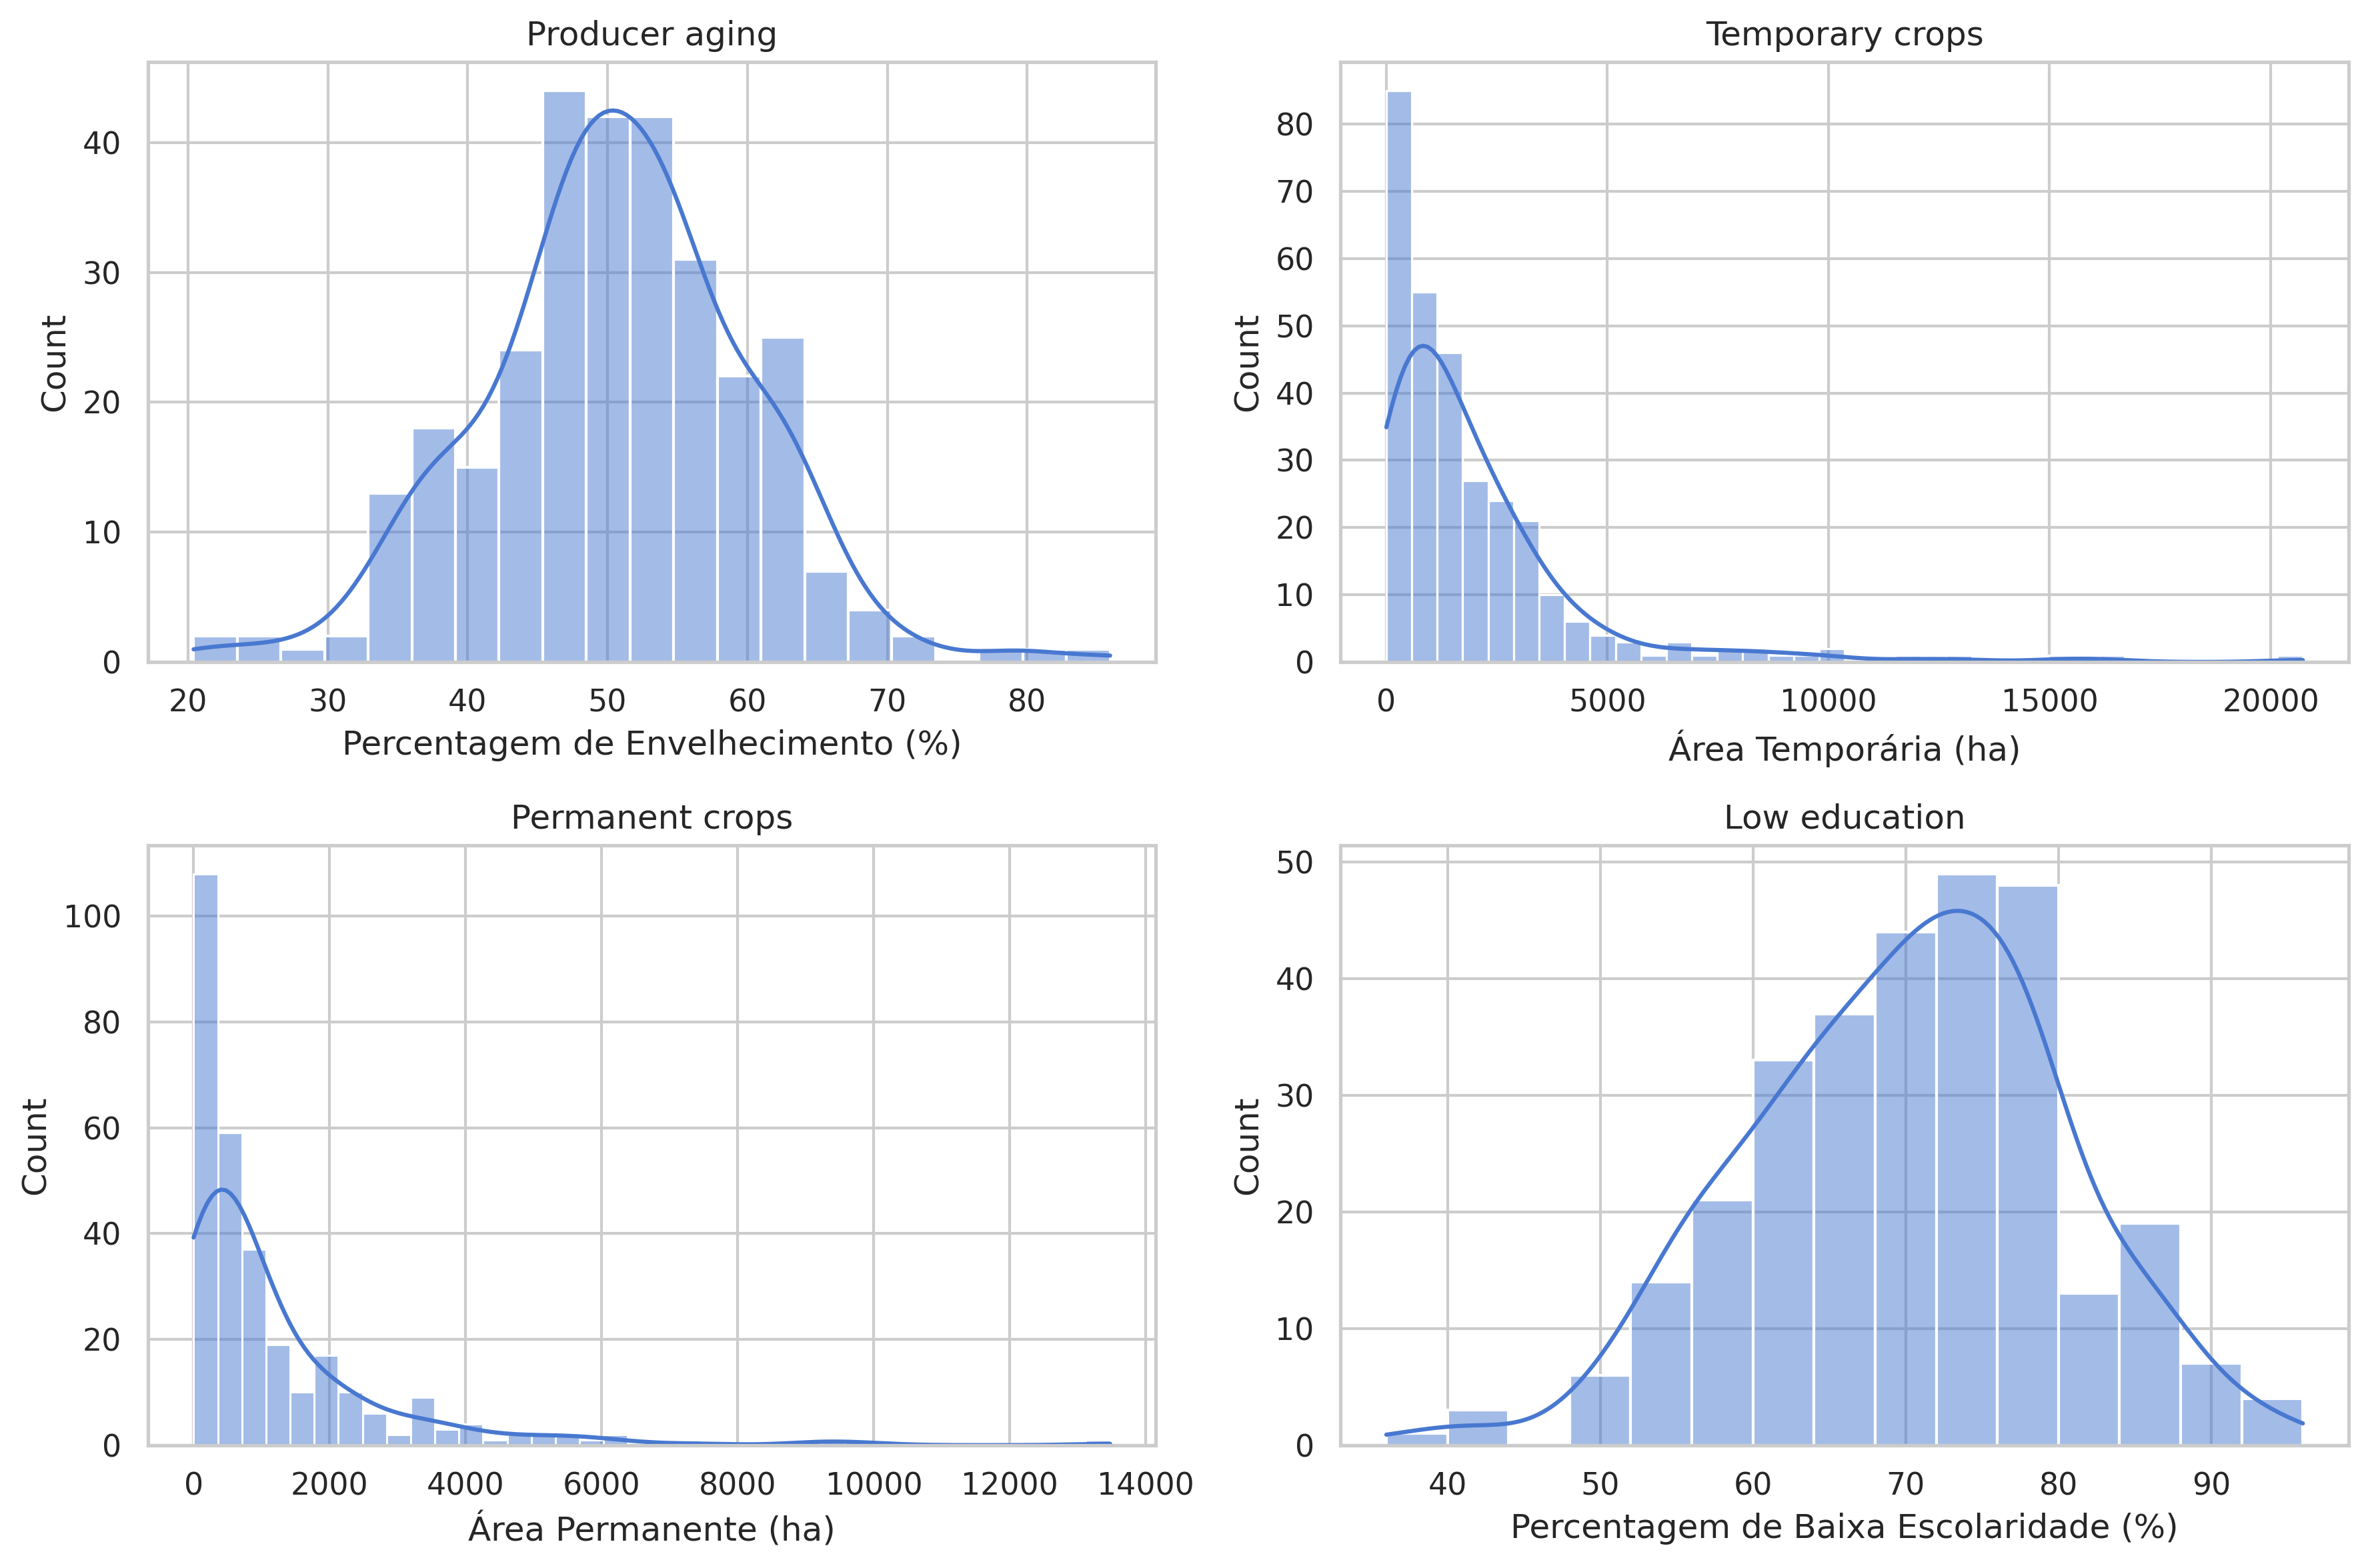

In [ ]:
fig, axes = plt.subplots(2,2,figsize=(12,8))

sns.histplot(df_final['Percentagem_Envelhecimento'], ax=axes[0,0], kde=True)
axes[0,0].set_xlabel("Percentagem de Envelhecimento (%)")
sns.histplot(df_final['Area_Temporarias'], ax=axes[0,1], kde=True)
axes[0,1].set_xlabel("Área Temporária (ha)")
sns.histplot(df_final['Area_Permanentes'], ax=axes[1,0], kde=True)
axes[1,0].set_xlabel("Área Permanente (ha)")
sns.histplot(df_final['Percentagem_Baixa_Escolaridade'], ax=axes[1,1], kde=True)
axes[1,1].set_xlabel("Percentagem de Baixa Escolaridade (%)")

axes[0,0].set_title("Producer aging")
axes[0,1].set_title("Temporary crops")
axes[1,0].set_title("Permanent crops")
axes[1,1].set_title("Low education")

plt.subplots_adjust(hspace=0.5) # Adjust vertical spacing between subplots
plt.tight_layout()
plt.show()

**Aging distribution:** The distribution of producer aging appears approximately symmetric and centered around 50%, suggesting that aging is widespread across Alentejo rather than concentrated in a limited subset of parishes. Extreme low and high values exist but occur infrequently.

**Temporary crop distribution:** Temporary crop percentages exhibit strong positive skewness, with most parishes showing relatively limited temporary cultivation while a smaller number of parishes concentrate large proportions of temporary agricultural activity. The long right tail and visible outliers suggest unequal spatial concentration of agricultural production.

**Permanent crop distribution:** Permanent crop percentages also display positive skewness, although less pronounced than temporary crops. Several extreme observations indicate specialization in agricultural systems such as vineyards or olive production.

**Education distribution:** Low educational attainment shows mild negative skewness because most observations cluster at high percentages. This suggests that low educational levels among agricultural producers are widespread across Alentejo.

Overall, demographic variables appear relatively concentrated around their means, whereas agricultural variables display stronger dispersion and skewness, suggesting considerable heterogeneity across parishes.

### Correlation matrix
Pairwise correlations were explored to identify potential relationships between demographic characteristics and agricultural structure.

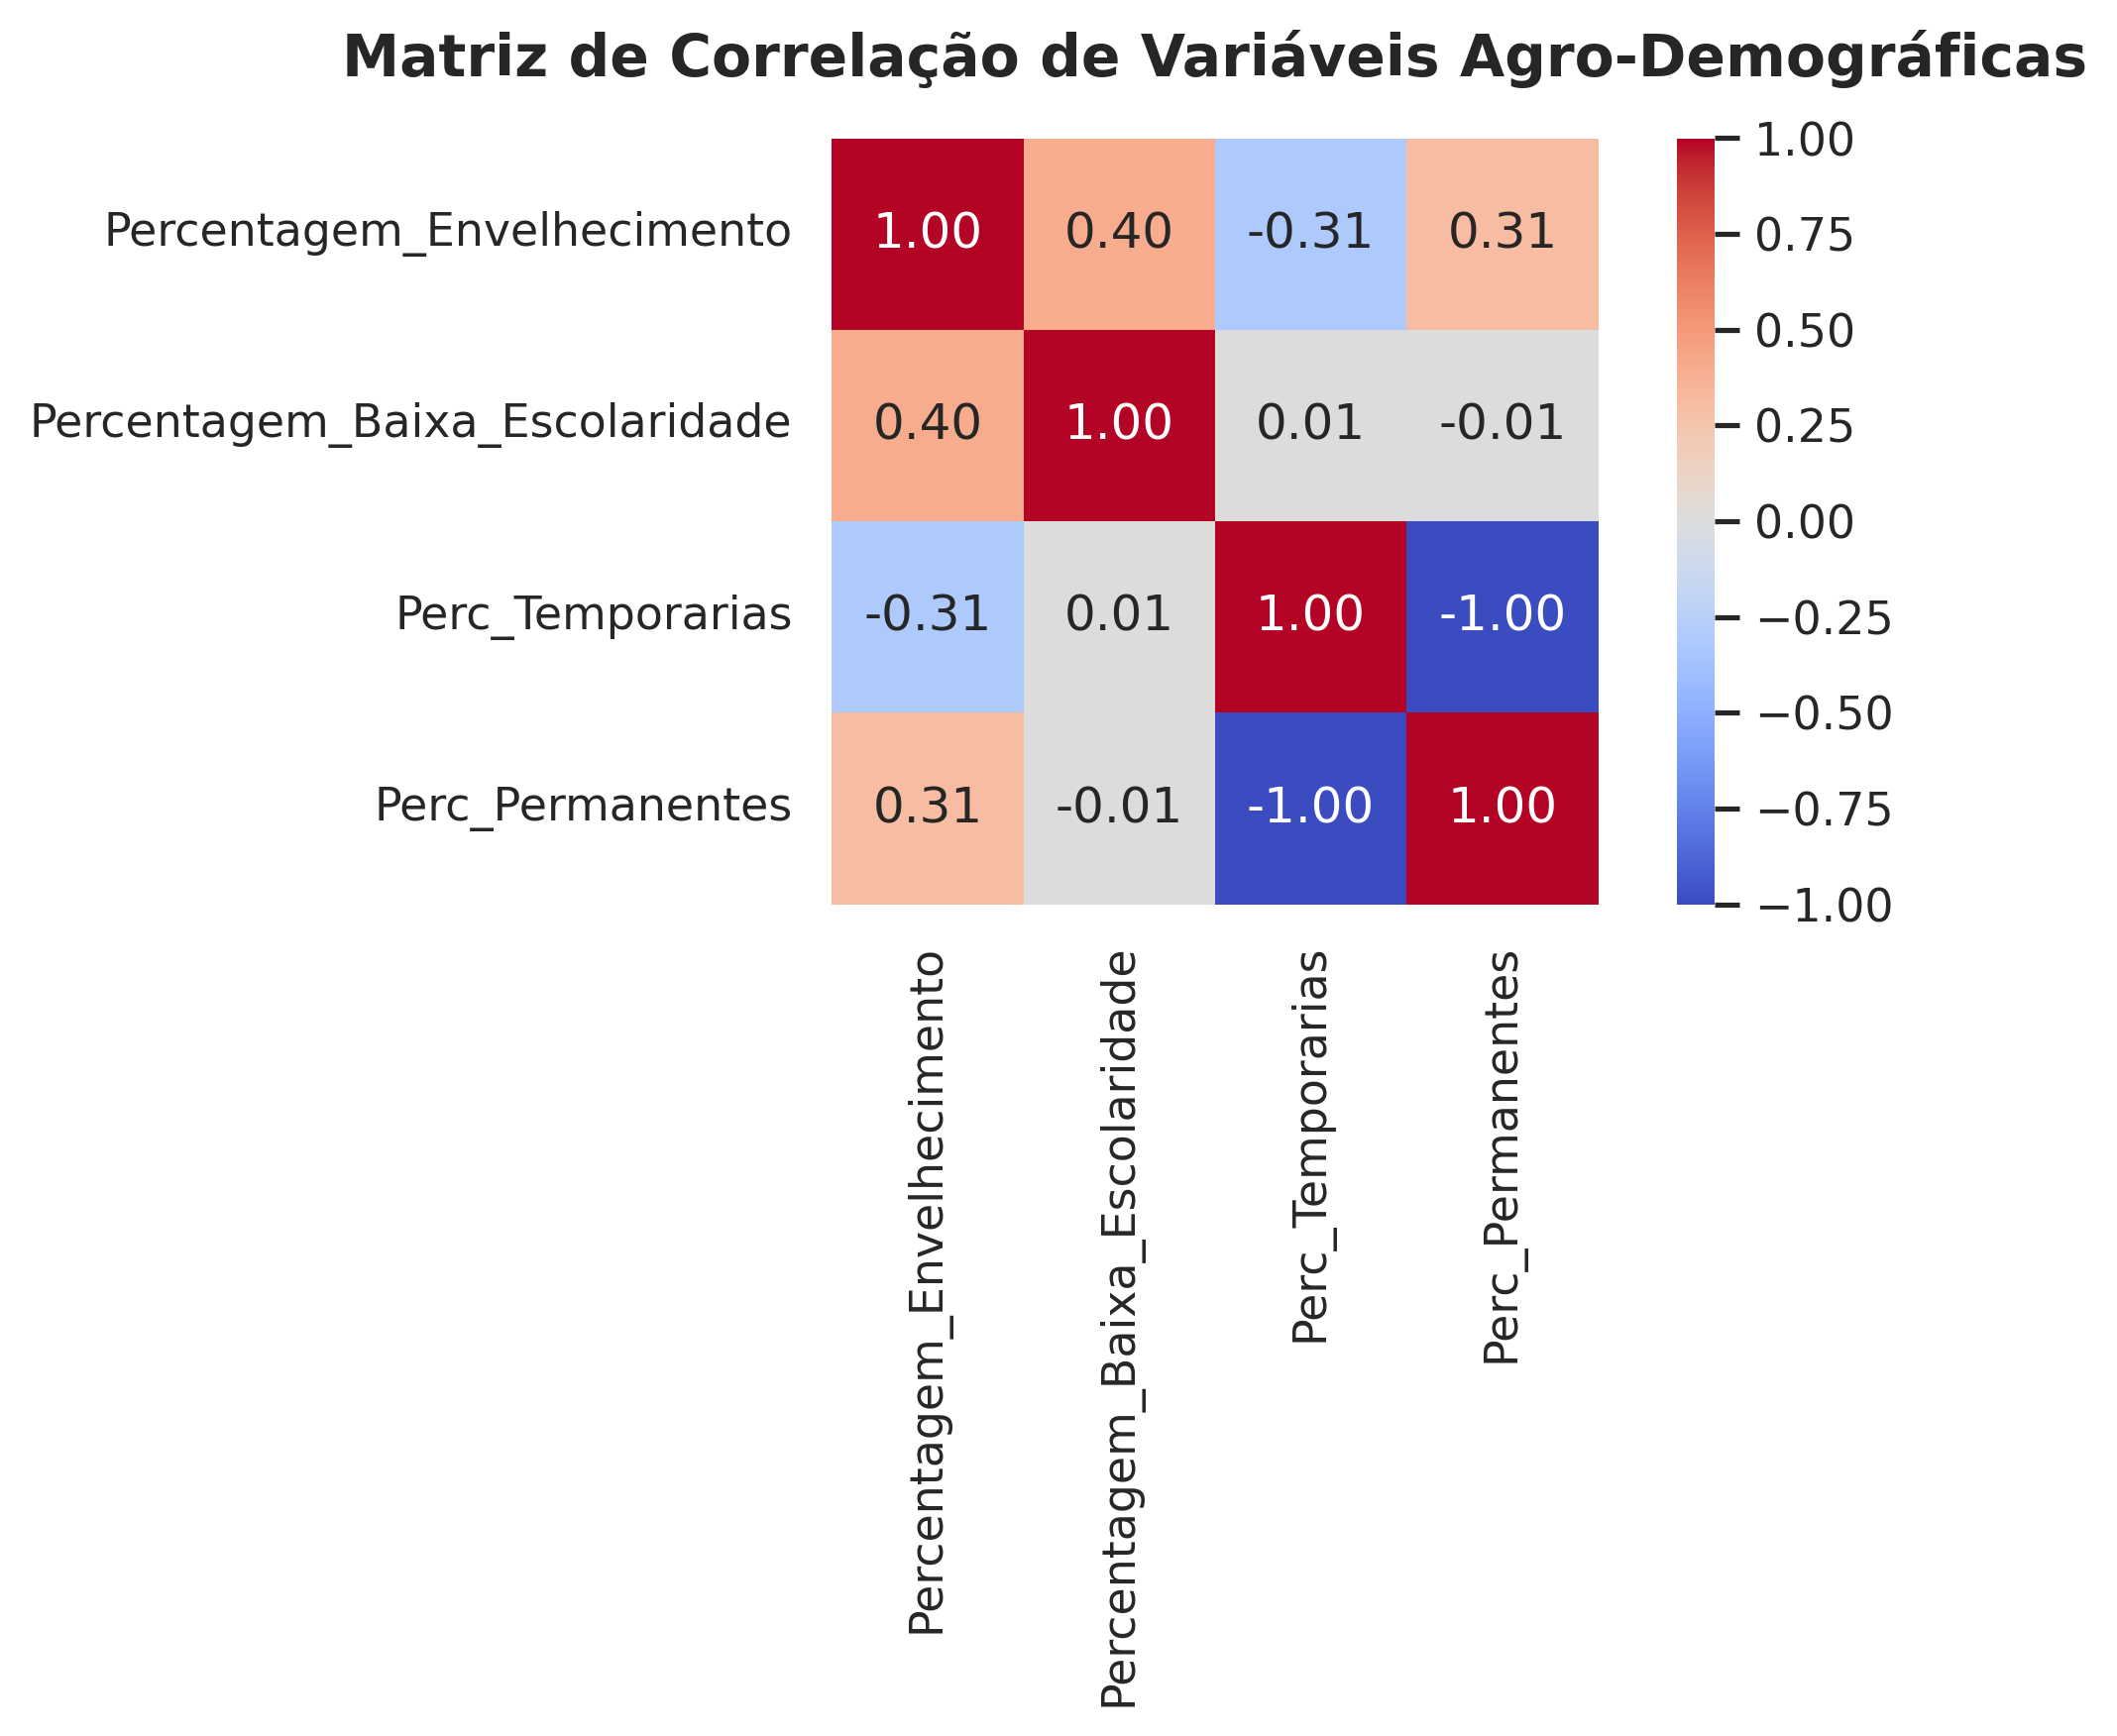

In [ ]:
# 3. Matriz de Correlação Simples (Mapa de Calor)
# Selecionar apenas as variáveis que queremos cruzar
cols_corr = ['Percentagem_Envelhecimento', 'Percentagem_Baixa_Escolaridade', 'Perc_Temporarias', 'Perc_Permanentes']
matriz_corr = df_final[cols_corr].corr()

# Desenhar o gráfico
plt.figure(figsize=(8,6))
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f", square=True)
plt.title("Matriz de Correlação de Variáveis Agro-Demográficas", pad=15, fontsize=14, fontweight='bold')
plt.tight_layout()

# Exportar imagem para o Colab e mostrar no ecrã
plt.savefig('Matriz_Correlacao.png')
plt.show()

Relationships:
* Aging vs low education: moderate positive correlation (r=0.40)
* Aging vs temporary crops: moderate negative correlation (r=-0.31)
* Aging vs permanent crops: moderate positive correlation (r=0.31)
* Temporary and permanent crop percentages are perfectly negatively correlated (r=-1.00) because they are complementary proportions summing to 100%
  * Perc_Permanentes=100-Perc_Temporarias
  * The perfect inverse correlation between temporary and permanent crops should not be interpreted as a causal relationship because both variables were constructed from the same total area

Correlation analysis suggests that demographic aging may be linked to agricultural specialization patterns, although these relationships remain moderate in magnitude.

### Scatterplots
Scatterplots with regression lines were used to visually assess the direction and strength of relationships between aging and agricultural structure.

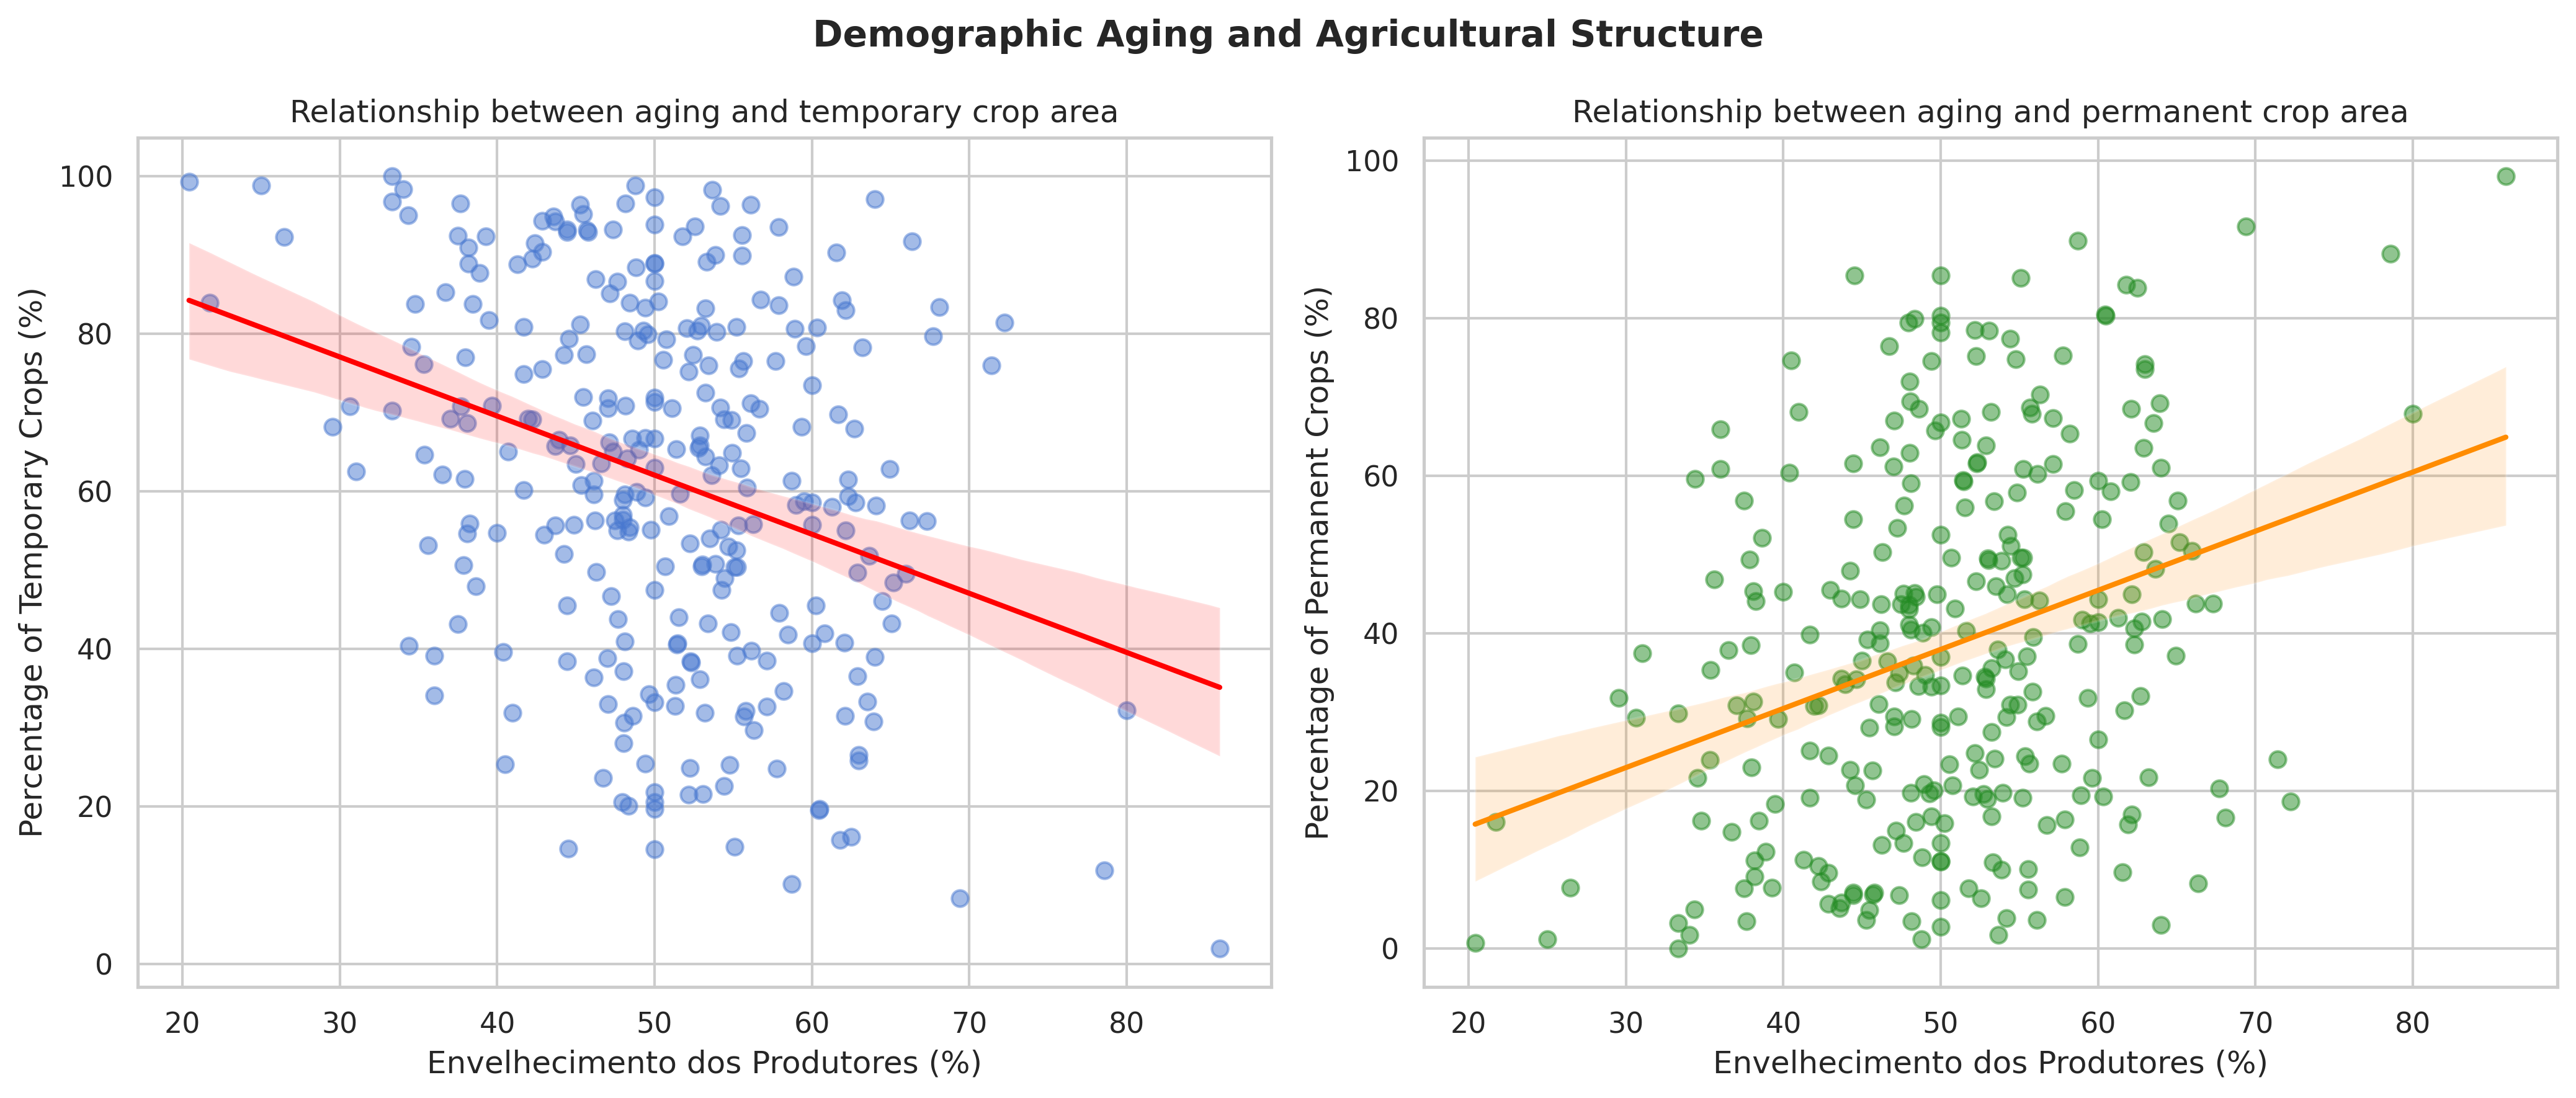

In [ ]:
# 4. Gráficos de Dispersão com Linha de Tendência (Regressão)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico A: Envelhecimento vs Culturas Temporárias (Esperamos uma linha a descer)
sns.regplot(data=df_final, x='Percentagem_Envelhecimento', y='Perc_Temporarias',
            scatter_kws={'alpha':0.5, 's':40}, line_kws={'color':'red', 'lw':2}, ax=ax1)
ax1.set_title("Relationship between aging and temporary crop area", fontsize=12)
ax1.set_xlabel("Envelhecimento dos Produtores (%)")
ax1.set_ylabel("Percentage of Temporary Crops (%)")

# Gráfico B: Envelhecimento vs Culturas Permanentes (Esperamos uma linha a subir)
sns.regplot(data=df_final, x='Percentagem_Envelhecimento', y='Perc_Permanentes',
            scatter_kws={'alpha':0.5, 's':40, 'color':'forestgreen'}, line_kws={'color':'darkorange', 'lw':2}, ax=ax2)
ax2.set_title("Relationship between aging and permanent crop area", fontsize=12)
ax2.set_xlabel("Envelhecimento dos Produtores (%)")
ax2.set_ylabel("Percentage of Permanent Crops (%)")

plt.suptitle('Demographic Aging and Agricultural Structure', fontsize=14, fontweight='bold')

plt.tight_layout()

# Exportar imagem para o Colab e mostrar no ecrã
plt.savefig('Graficos_Dispersao.png')
plt.show()

The downward trend for temporary crops and upward trend for permanent crops suggest that older producer populations may be associated with different patterns of agricultural specialization. However, the mechanisms underlying this relationship cannot be directly inferred from the available data.

### Boxplots
Aging categories were created using terciles to compare agricultural patterns across demographic profiles.

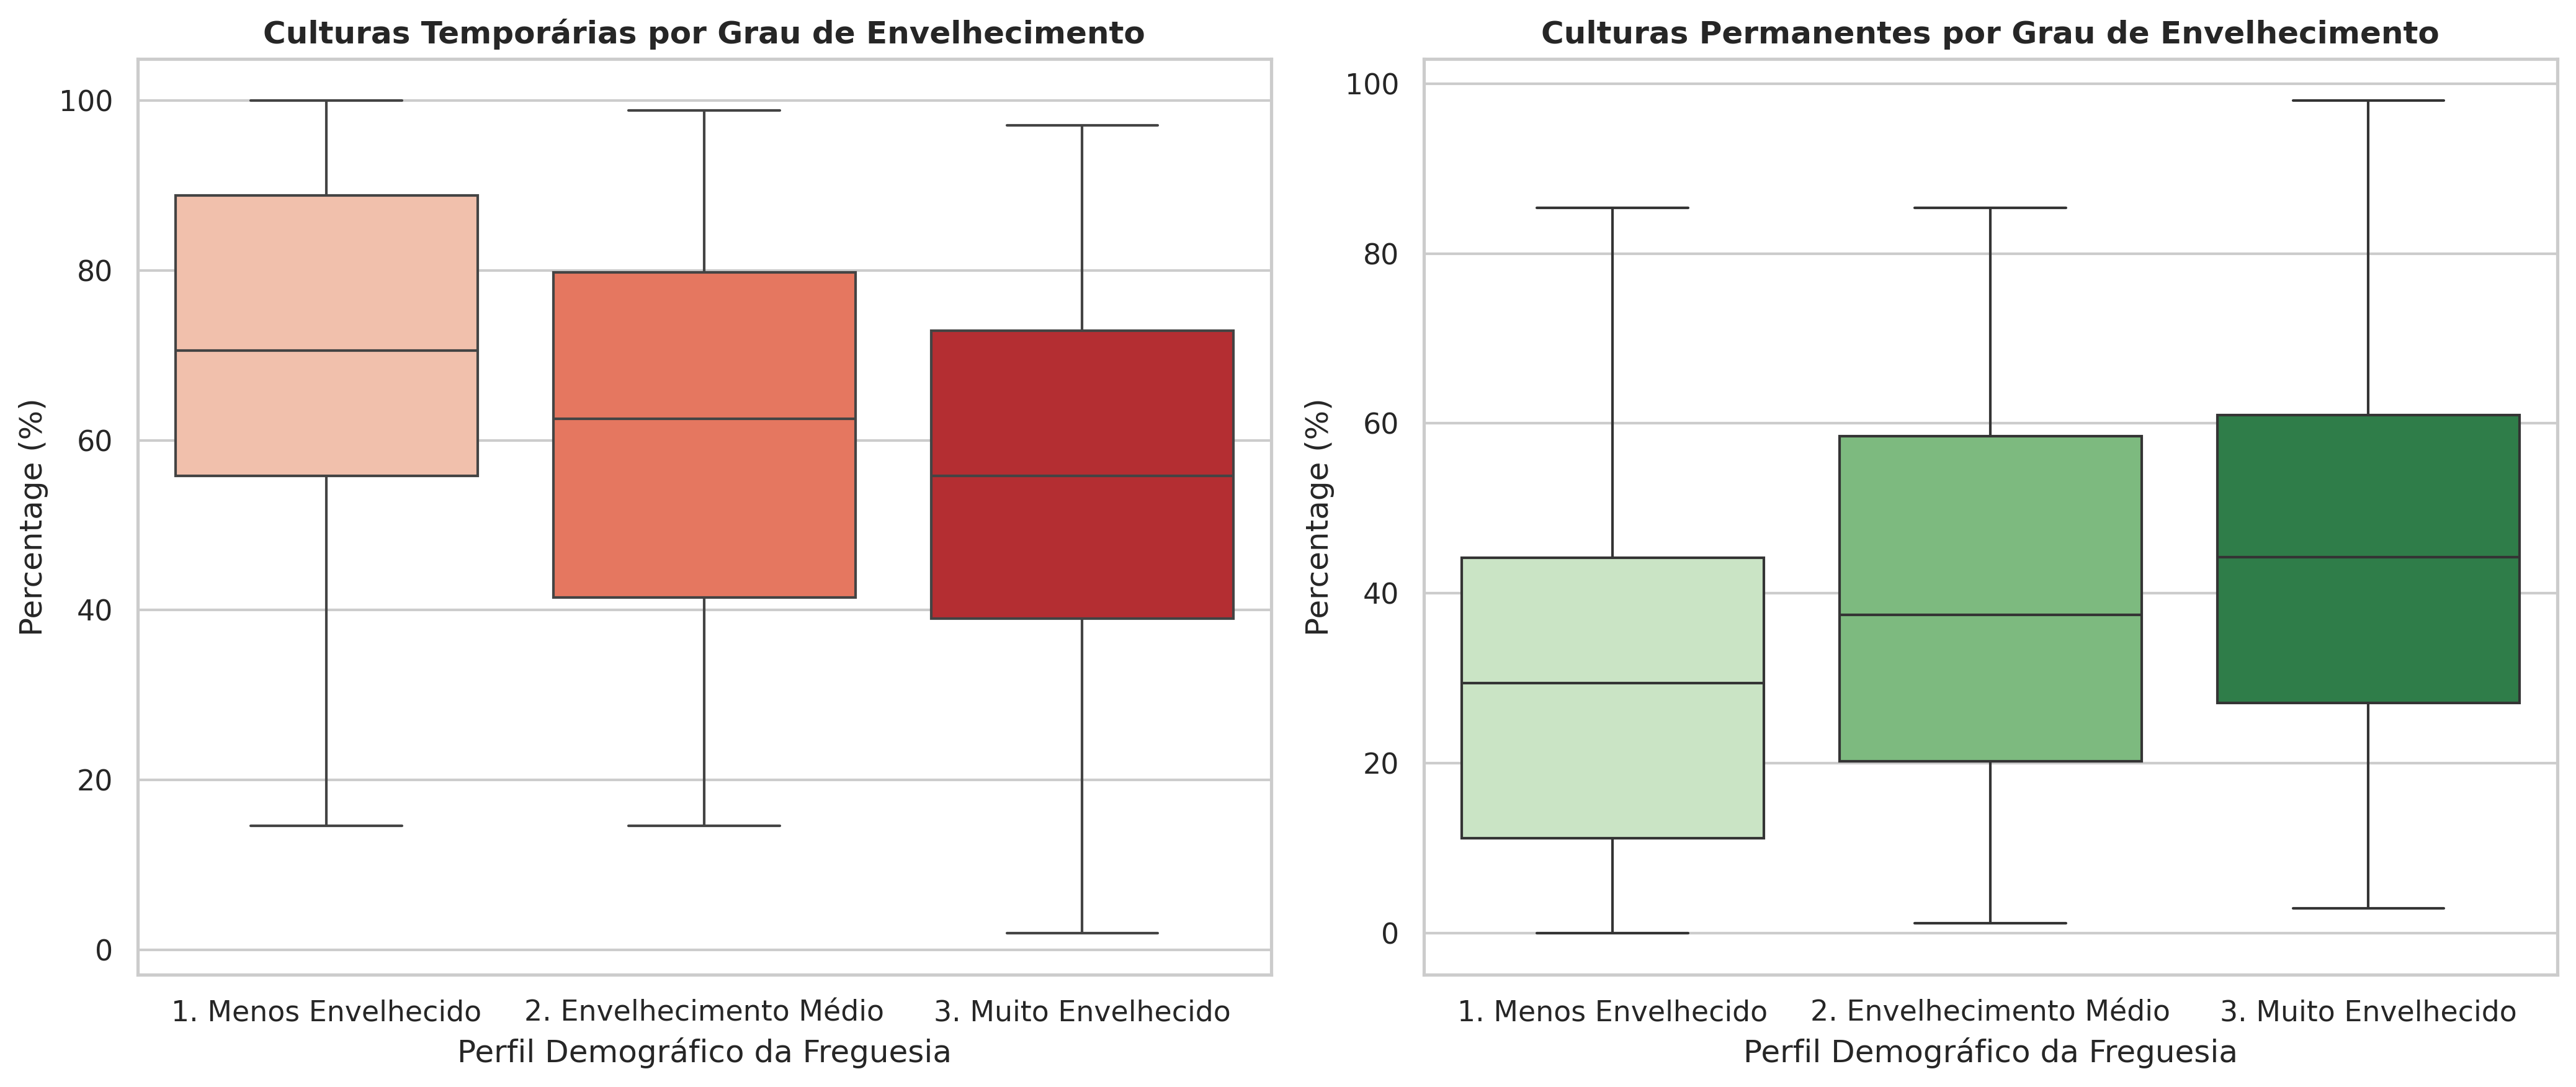

In [ ]:
# 1. Criar as categorias de envelhecimento por tercis
tercil_33 = df_final['Percentagem_Envelhecimento'].quantile(0.33)
tercil_66 = df_final['Percentagem_Envelhecimento'].quantile(0.66)

condicoes = [
    (df_final['Percentagem_Envelhecimento'] <= tercil_33),
    (df_final['Percentagem_Envelhecimento'] > tercil_33) & (df_final['Percentagem_Envelhecimento'] <= tercil_66),
    (df_final['Percentagem_Envelhecimento'] > tercil_66)
]
nomes_categorias = ['1. Menos Envelhecido', '2. Envelhecimento Médio', '3. Muito Envelhecido']
df_final['Categoria_Idade'] = np.select(condicoes, nomes_categorias, default='')

# 2. Configurar o estilo visual académico
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.dpi': 300, 'font.family': 'sans-serif'})

# 3. Desenhar os Boxplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico A: Culturas Temporárias
sns.boxplot(data=df_final, x='Categoria_Idade', y='Perc_Temporarias', hue='Categoria_Idade', palette='Reds', ax=ax1)
ax1.set_title("Culturas Temporárias por Grau de Envelhecimento", fontsize=12, fontweight='bold')
ax1.set_xlabel("Perfil Demográfico da Freguesia")
ax1.set_ylabel("Percentage (%)")

# Gráfico B: Culturas Permanentes
sns.boxplot(data=df_final, x='Categoria_Idade', y='Perc_Permanentes', hue='Categoria_Idade', palette='Greens', ax=ax2)
ax2.set_title("Culturas Permanentes por Grau de Envelhecimento", fontsize=12, fontweight='bold')
ax2.set_xlabel("Perfil Demográfico da Freguesia")
ax2.set_ylabel("Percentage (%)")

plt.tight_layout()
plt.savefig('Grafico_Boxplot_Premium.png')
plt.show()

Median temporary crop prevalence appears progressively lower among highly aged parishes, while permanent crop prevalence shows the opposite tendency. This pattern reinforces earlier observations from correlation and scatterplot analyses.

#### **Summary of EDA findings**

Exploratory analyses consistently indicate three main patterns:
*   Older producer populations tend to exhibit lower temporary crop prevalence.
*   Aging is positively associated with lower educational attainment.
*   Agricultural activity displays substantial heterogeneity across Alentejo parishes.

## 4. Inferential statistics

### Correlation significance
Pearson correlation tests were performed to determine whether observed relationships were statistically distinguishable from random variation.

In [ ]:
from scipy.stats import pearsonr

corr,p = pearsonr(df_final['Percentagem_Envelhecimento'], df_final['Perc_Temporarias'])

print(corr,p)

-0.3103898287731783 4.2384850065660985e-08


A statistically significant negative relationship was observed between producer aging and temporary crop prevalence (r=-0.31, p<0.001). Although the relationship is relatively weak in magnitude, the result suggests that aging tends to correspond to lower temporary crop activity.

### ANOVA
Analysis of Variance (ANOVA) was used to evaluate whether temporary crop prevalence differs across aging categories.

In [ ]:
from scipy.stats import f_oneway

grupo1 = df_final[df_final['Categoria_Idade']=="1. Menos Envelhecido"]['Perc_Temporarias']

grupo2 = df_final[df_final['Categoria_Idade']=="2. Envelhecimento Médio"]['Perc_Temporarias']

grupo3 = df_final[df_final['Categoria_Idade']=="3. Muito Envelhecido"]['Perc_Temporarias']

f,p = f_oneway(grupo1, grupo2, grupo3)

print(f,p)

12.085274257266207 9.010087155455123e-06


* ANOVA results indicate statistically significant differences between aging groups (F=12.09, p<0.001).

* Parishes with lower aging levels tend to present higher temporary crop prevalence, whereas highly aged parishes generally exhibit lower temporary crop prevalence.

* This supports the hypothesis that demographic structure is associated with agricultural land-use patterns.

These findings suggest that demographic differences correspond to observable differences in agricultural organization.

### Multiple regression
Multiple linear regression was used to evaluate the simultaneous effects of aging and educational characteristics on temporary crop prevalence.

In [ ]:
import statsmodels.api as sm

X=df_final[['Percentagem_Envelhecimento', 'Percentagem_Baixa_Escolaridade']]

X=sm.add_constant(X)

y=df_final['Perc_Temporarias']

modelo=sm.OLS(y,X).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:       Perc_Temporarias   R-squared:                       0.118
Model:                            OLS   Adj. R-squared:                  0.112
Method:                 Least Squares   F-statistic:                     19.81
Date:                Tue, 30 Jun 2026   Prob (F-statistic):           8.42e-09
Time:                        19:34:05   Log-Likelihood:                -1340.5
No. Observations:                 299   AIC:                             2687.
Df Residuals:                     296   BIC:                             2698.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

#### **Key findings:**

* The regression model explains approximately 11.8% of the variation in temporary crop prevalence. While demographic characteristics contribute significantly to agricultural structure, most variation remains associated with additional factors not included in the model, such as environmental conditions, market dynamics, farm size, and institutional influences.

* Producer aging exhibits the strongest relationship with temporary crop prevalence (β=-0.91, p<0.001). In practical terms, a 10 percentage-point increase in agricultural aging is associated with an estimated 9 percentage-point reduction in temporary crop prevalence.

* Lower educational attainment shows a weaker but significant positive association (β=0.36, p<0.01). A 10 percentage-point increase in low educational attainment corresponds to an estimated increase of approximately 3.6 percentage points in temporary crop prevalence.

* These findings suggest that demographic characteristics are associated with agricultural structure, although substantial unexplained variation remains.

### Regression diagnostics
#### Residual analysis
Regression assumptions were evaluated through residual diagnostics.

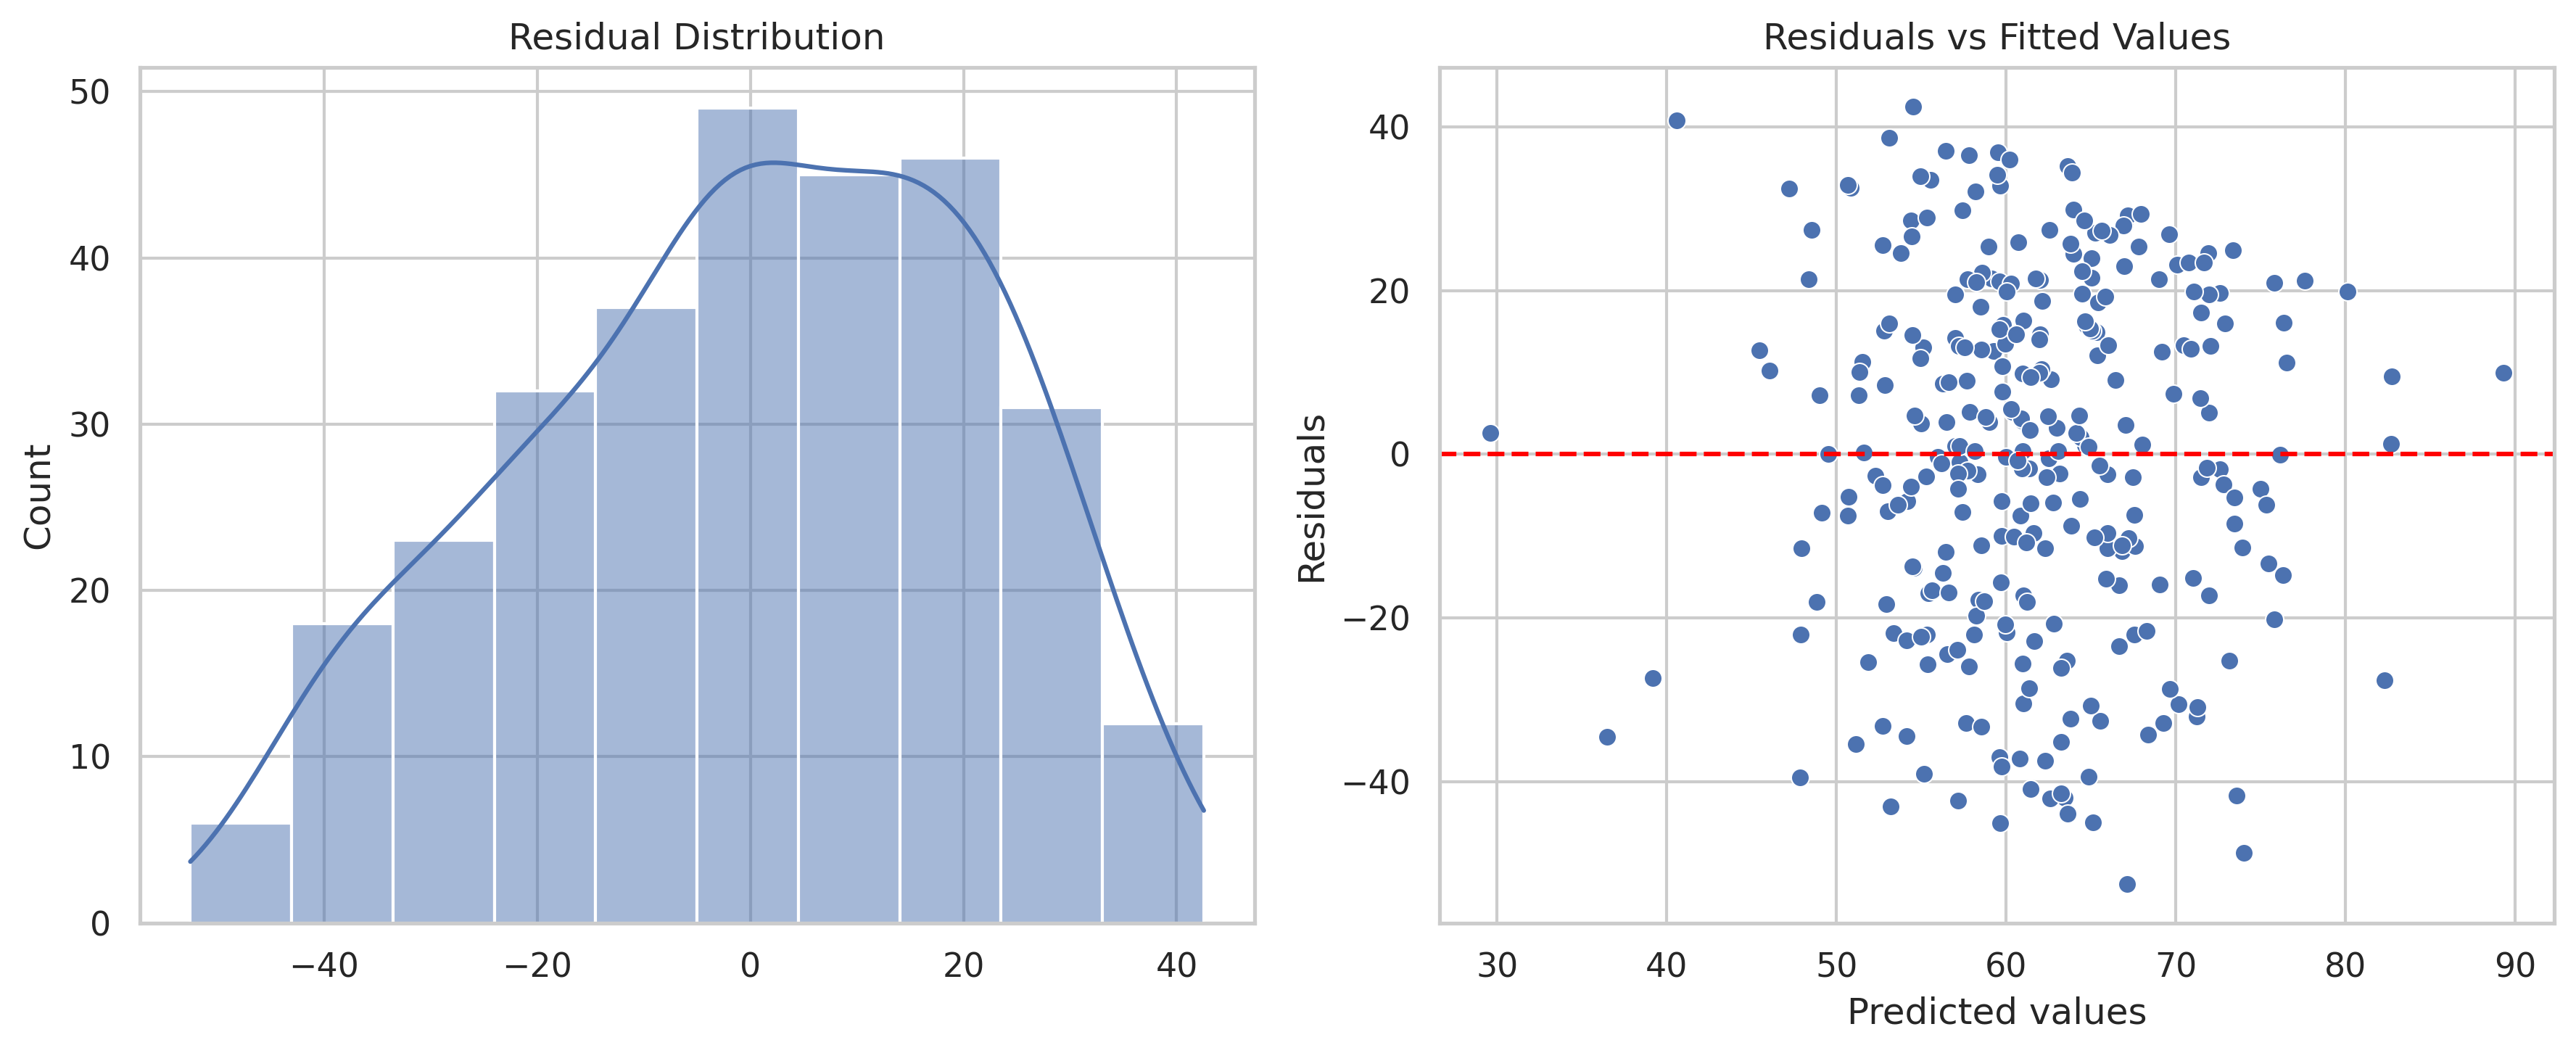

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

# Residual distribution
sns.histplot(modelo.resid, kde=True, ax=ax[0])
ax[0].set_title("Residual Distribution")

# Residuals vs fitted values
sns.scatterplot(
    x=modelo.fittedvalues,
    y=modelo.resid,
    ax=ax[1]
)

ax[1].axhline(
    y=0,
    linestyle='--',
    color='red'
)

ax[1].set_title("Residuals vs Fitted Values")
ax[1].set_xlabel("Predicted values")
ax[1].set_ylabel("Residuals")

plt.tight_layout()
plt.show()

#### Multicollinearity
Variance Inflation Factors (VIF) were calculated to verify whether predictors exhibited problematic levels of correlation.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()

vif["Variable"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(
        X.values,i
    )
    for i in range(X.shape[1])
]

print(vif)

                         Variable        VIF
0                           const  56.416854
1      Percentagem_Envelhecimento   1.189974
2  Percentagem_Baixa_Escolaridade   1.189974


Residual distributions appear approximately centered around zero, although some departures from normality are present according to the Jarque–Bera test (p<0.01). The residual versus fitted plot does not indicate strong heteroscedasticity patterns, and VIF values close to 1 suggest negligible multicollinearity.

### Interactive exploration

In [ ]:
import plotly.express as px

fig=px.scatter(
    df_final,
    x='Percentagem_Envelhecimento',
    y='Perc_Temporarias',
    color='Percentagem_Baixa_Escolaridade',
    hover_name='Nome_Freguesia'
)

fig.show()

The interactive figure allows detailed inspection of parish-level observations and identification of local outliers.

### Hypothesis summary
| Hypothesis |              Result | Evidence                                                               |
| ---------- | ------------------: | ---------------------------------------------------------------------- |
| H1         |           Supported | Aging negatively associated with temporary crops (β=-0.91, p<0.001)    |
| H2         |           Supported | Positive correlation between aging and permanent crops (r=0.31)        |
| H3         |           Supported | Moderate positive correlation between aging and low education (r=0.40) |
| H4         | Partially supported | Regression significant but low explanatory power (R²=0.118)            |

## 5. Final visualization product

## 6. Discussion
Key findings:
*   Average agricultural aging = 50.6%
*   Aging negatively associated with temporary crops
*   Lower education linked with older producer populations
*   Demographics explain only part of agricultural variation (R²=11.8%)
*   Additional environmental factors likely influence agricultural systems

The analyses consistently suggest that demographic aging is associated with differences in agricultural organization across Alentejo parishes. Older producer populations tend to exhibit lower prevalence of temporary crops and relatively greater prevalence of permanent agricultural systems. One possible explanation is that demographic differences influence agricultural management decisions; however, causal mechanisms cannot be established from this analysis. Temporary and permanent crop systems may differ in labor requirements, investment structures, or management practices, but these mechanisms were not directly evaluated. Demographic characteristics nevertheless explain only a limited portion of agricultural variation, indicating that environmental conditions, market incentives and farm structures also play important roles.

### Study limitations
Several limitations should be acknowledged:
* The analysis is cross-sectional and does not establish causality
* Agricultural land-use patterns may also depend on environmental, economic and institutional factors not included in the datase
* The regression model explains a limited proportion of variance, suggesting omitted variables
* Some variables were transformed into percentages, which may hide differences in absolute agricultural scale between parishes
* Spatial dependence between neighboring parishes was not modeled
* Administrative units differ substantially in area and agricultural structure

## 7. Conclusion
The results suggest that demographic processes may influence agricultural organization within Alentejo. Older producer populations appear associated with a lower prevalence of temporary crops and a relatively greater prevalence of permanent crops. One possible explanation is that permanent crop systems may require different labor dynamics and management practices than temporary crop systems. However, these findings should be interpreted cautiously because agricultural decisions also depend on environmental, economic and institutional conditions.

## 8. References
*   Instituto Nacional de Estatística (INE). Agricultural Census Database. Portugal.



## 9. Final visualization product

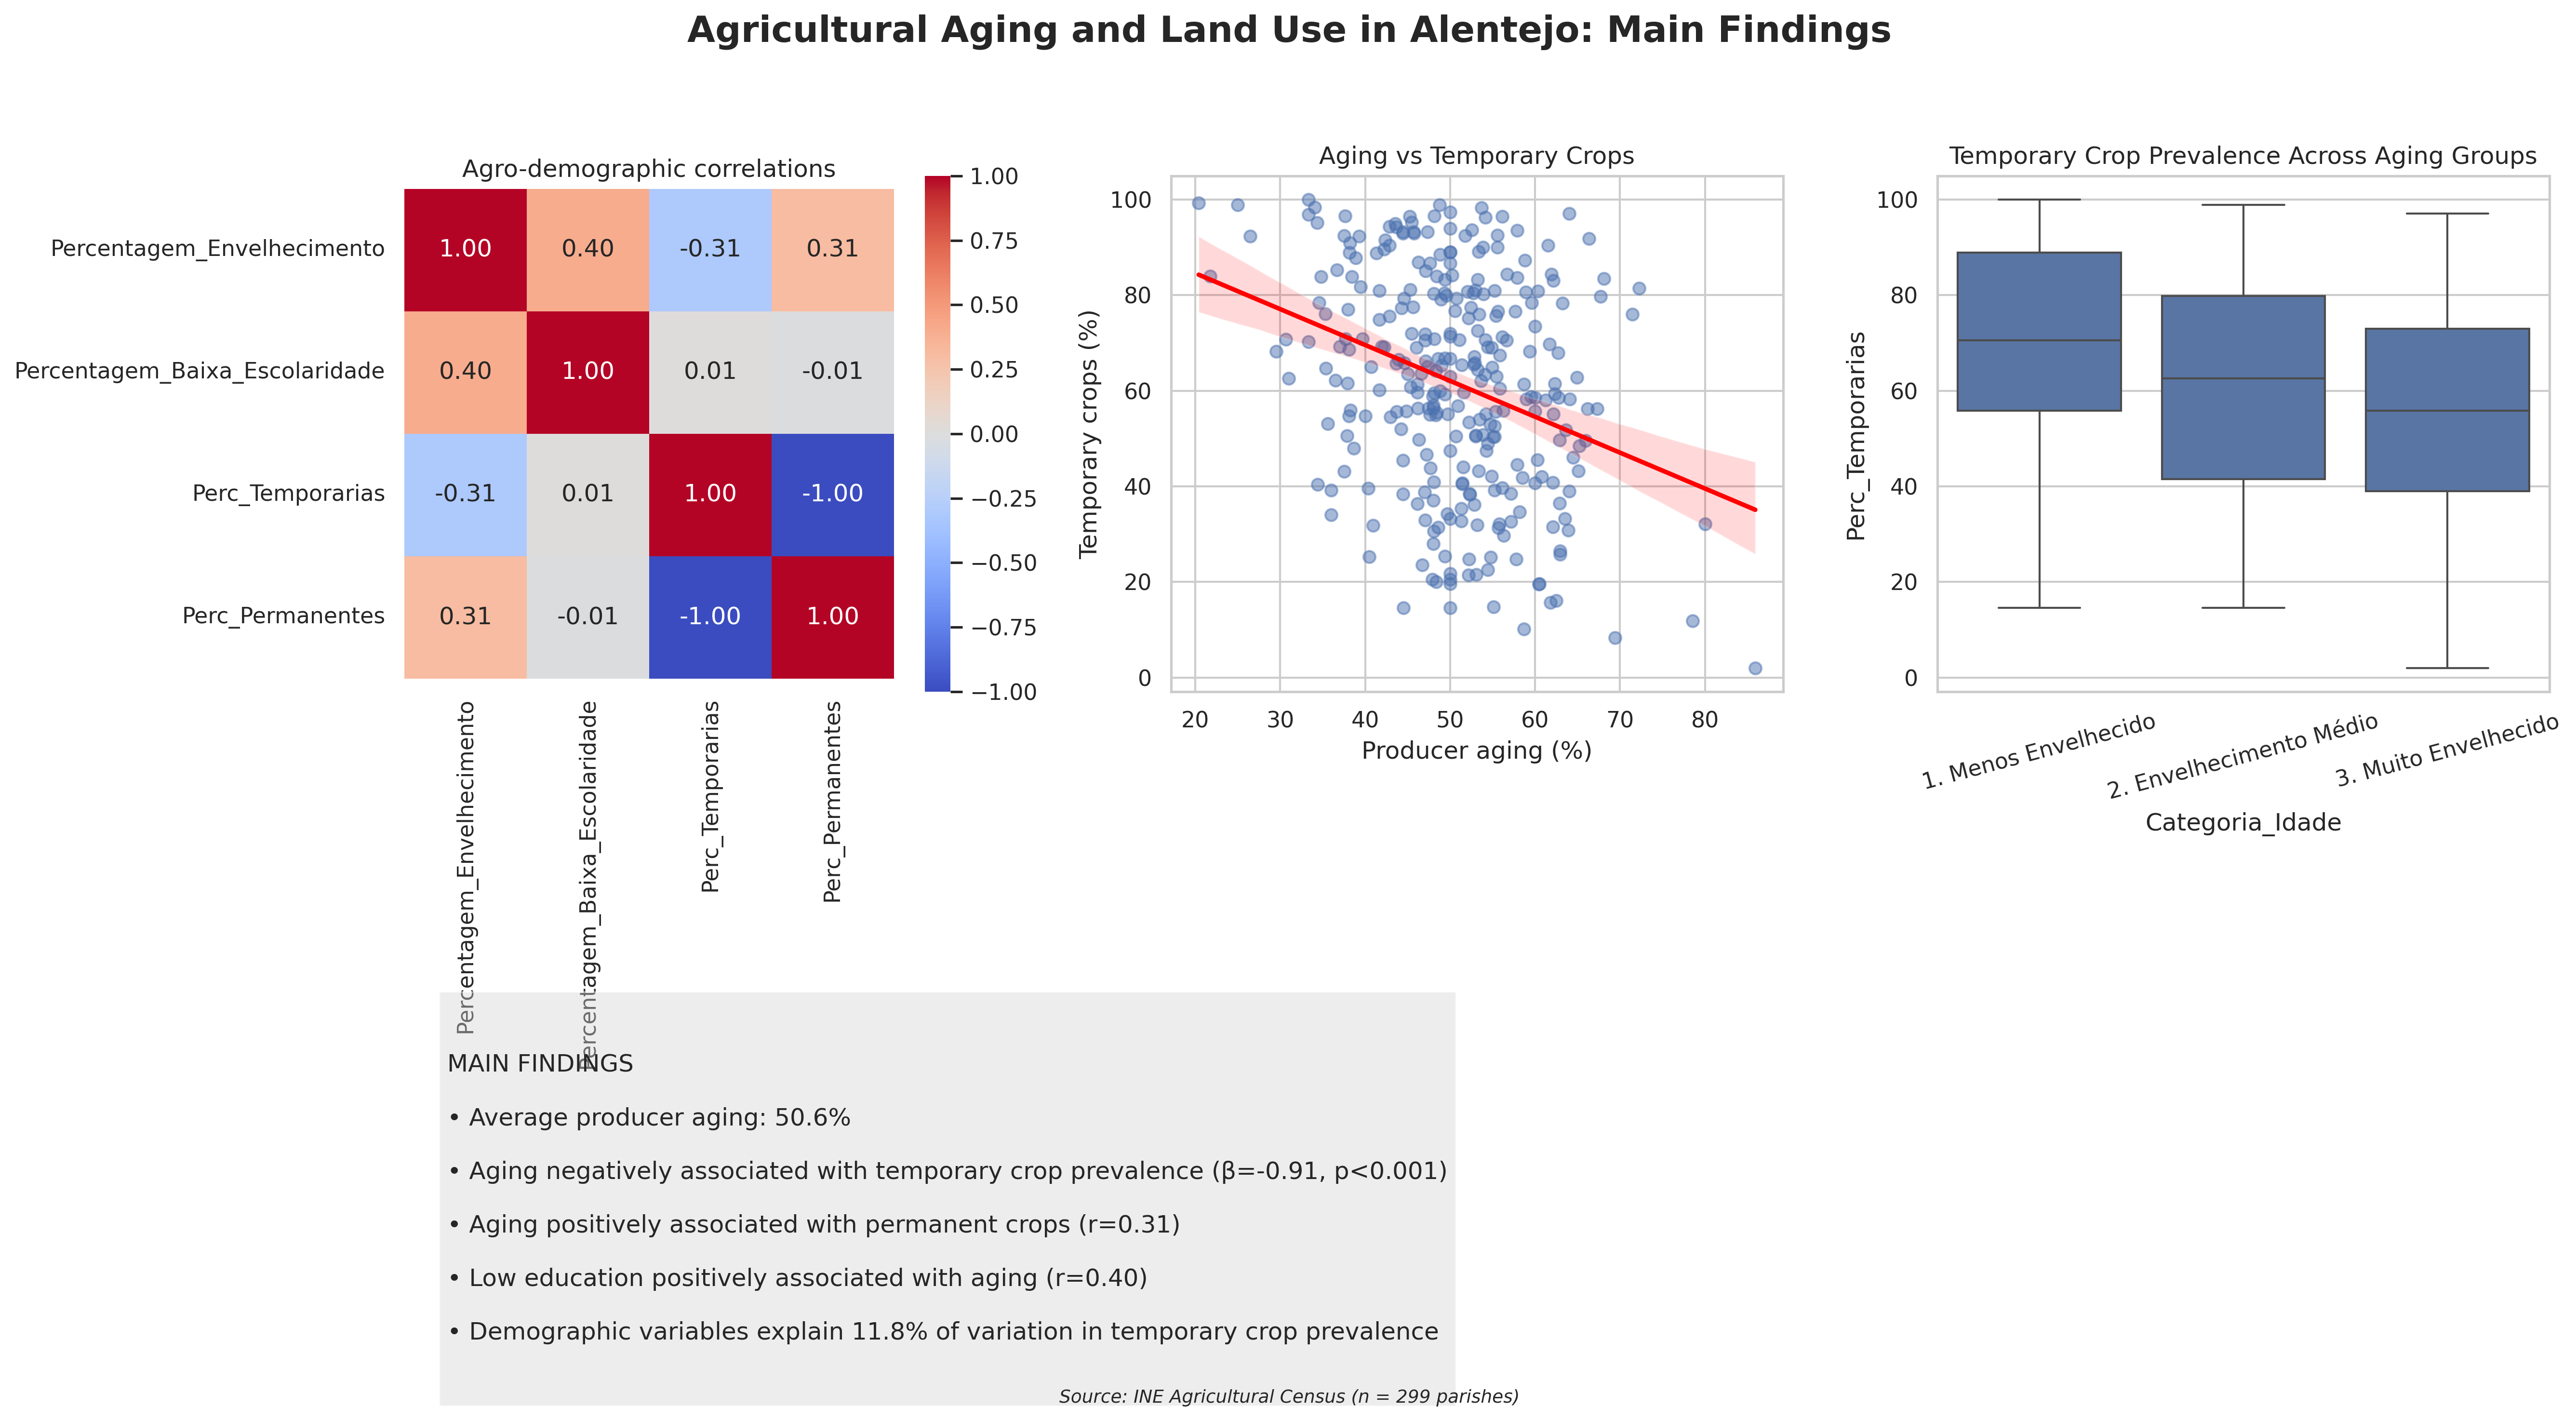

In [ ]:
# ======================================================
# FINAL VISUAL STORYTELLING DASHBOARD
# ======================================================

fig = plt.figure(figsize=(18,10))

gs = fig.add_gridspec(
    2,
    3,
    height_ratios=[3,1]
)

fig.suptitle(
    "Agricultural Aging and Land Use in Alentejo: Main Findings",
    fontsize=18,
    fontweight='bold'
)

# -----------------------------
# 1. Correlation heatmap
# -----------------------------

ax1=fig.add_subplot(gs[0,0])

sns.heatmap(
    matriz_corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    square=True,
    ax=ax1
)

ax1.set_title(
    "Agro-demographic correlations"
)

# -----------------------------
# 2. Scatterplot
# -----------------------------

ax2=fig.add_subplot(gs[0,1])

sns.regplot(
    data=df_final,
    x='Percentagem_Envelhecimento',
    y='Perc_Temporarias',
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'},
    ax=ax2
)

ax2.set_title(
    "Aging vs Temporary Crops"
)

ax2.set_xlabel(
    "Producer aging (%)"
)

ax2.set_ylabel(
    "Temporary crops (%)"
)

# -----------------------------
# 3. Boxplot
# -----------------------------

ax3=fig.add_subplot(gs[0,2])

sns.boxplot(
    data=df_final,
    x='Categoria_Idade',
    y='Perc_Temporarias',
    ax=ax3
)

ax3.set_title(
    "Temporary Crop Prevalence Across Aging Groups"
)

ax3.tick_params(
    axis='x',
    rotation=15
)

# -----------------------------
# Text summary panel
# -----------------------------

ax4=fig.add_subplot(gs[1,:])

ax4.axis('off')

summary = f"""

MAIN FINDINGS

• Average producer aging: {df_final['Percentagem_Envelhecimento'].mean():.1f}%

• Aging negatively associated with temporary crop prevalence (β=-0.91, p<0.001)

• Aging positively associated with permanent crops (r=0.31)

• Low education positively associated with aging (r=0.40)

• Demographic variables explain 11.8% of variation in temporary crop prevalence

"""

ax4.text(
    0.02,
    0.8,
    summary,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(
        facecolor='lightgray',
        alpha=0.4
    )
)

fig.text(
    0.5,
    0.02,
    "Source: INE Agricultural Census (n = 299 parishes)",
    ha='center',
    fontsize=9,
    style='italic'
)

plt.tight_layout(rect=[0,0.05,1,0.95])
plt.savefig(
    "Final_Storytelling_Dashboard.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()